<a href="https://colab.research.google.com/github/Shrutika2026/Sqrock-DataScience-Week1-Task2/blob/main/DataScience_Week1_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mean Squared Error: 6.31
R-squared Accuracy: 0.99


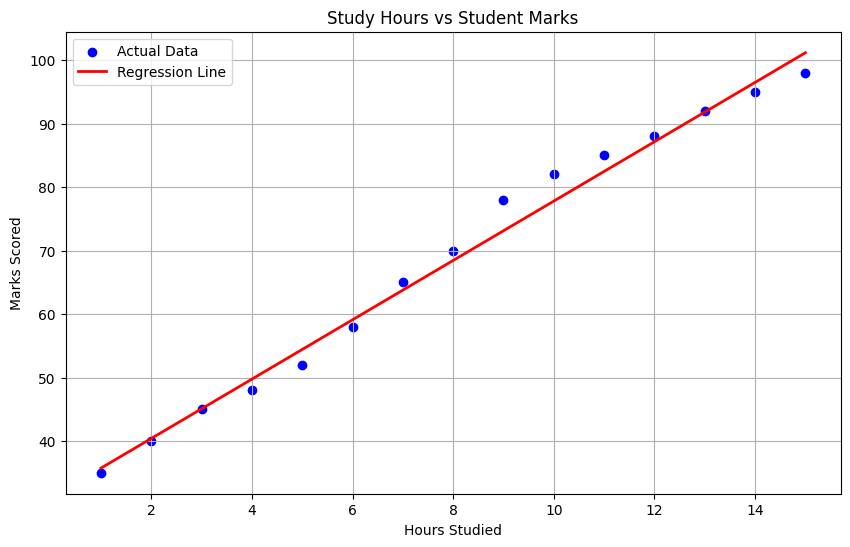

In [ ]:
"""
Mini-project: Linear Regression for predicting student marks from study hours.

This script:
1) Creates a small synthetic dataset.
2) Splits data into training and testing sets.
3) Trains a Linear Regression model.
4) Evaluates performance using MSE and R^2.
5) Visualizes the regression fit.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


def create_dataset(data: Dict[str, List[float]]) -> pd.DataFrame:
    """
    Create a validated pandas DataFrame from raw dictionary data.

    Args:
        data: Dictionary containing:
            - 'Hours': list of numeric study-hour values.
            - 'Marks': list of numeric mark values.

    Returns:
        A pandas DataFrame with columns ['Hours', 'Marks'].

    Raises:
        TypeError: If `data` is not a dictionary or values are not list-like.
        KeyError: If required keys ('Hours', 'Marks') are missing.
        ValueError: If lists are empty, lengths mismatch, or contain non-numeric values.
    """
    if not isinstance(data, dict):
        raise TypeError("Input `data` must be a dictionary.")

    required_keys = {"Hours", "Marks"}
    missing = required_keys - set(data.keys())
    if missing:
        raise KeyError(f"Missing required keys: {missing}")

    hours = data["Hours"]
    marks = data["Marks"]

    if not isinstance(hours, (list, tuple, np.ndarray)) or not isinstance(
        marks, (list, tuple, np.ndarray)
    ):
        raise TypeError("'Hours' and 'Marks' must be list, tuple, or numpy array.")

    if len(hours) == 0 or len(marks) == 0:
        raise ValueError("'Hours' and 'Marks' must not be empty.")

    if len(hours) != len(marks):
        raise ValueError(
            f"Length mismatch: len(Hours)={len(hours)} != len(Marks)={len(marks)}"
        )

    # Validate numeric values
    try:
        hours = [float(x) for x in hours]
        marks = [float(y) for y in marks]
    except (TypeError, ValueError) as e:
        raise ValueError("All values in 'Hours' and 'Marks' must be numeric.") from e

    df = pd.DataFrame({"Hours": hours, "Marks": marks})
    return df


def preprocess_data(
    df: pd.DataFrame, test_size: float = 0.2, random_state: int = 42
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Prepare feature and target variables, then split into train and test sets.

    Args:
        df: Input DataFrame containing 'Hours' and 'Marks'.
        test_size: Fraction of dataset to reserve for testing (0 < test_size < 1).
        random_state: Random seed for reproducibility.

    Returns:
        Tuple of (X_train, X_test, y_train, y_test).

    Raises:
        TypeError: If `df` is not a pandas DataFrame.
        KeyError: If required columns are missing.
        ValueError: If `df` is too small or has invalid `test_size`.
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("`df` must be a pandas DataFrame.")

    required_cols = {"Hours", "Marks"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"DataFrame missing required columns: {missing}")

    if not (0 < test_size < 1):
        raise ValueError("`test_size` must be between 0 and 1 (exclusive).")

    if len(df) < 5:
        raise ValueError("Dataset is too small. Provide at least 5 rows.")

    X = df[["Hours"]]
    y = df["Marks"]

    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )
    except Exception as e:
        raise RuntimeError("Failed during train/test split.") from e

    return X_train, X_test, y_train, y_test


def train_model(X_train: pd.DataFrame, y_train: pd.Series) -> LinearRegression:
    """
    Train a Linear Regression model.

    Args:
        X_train: Training features DataFrame.
        y_train: Training target Series.

    Returns:
        Trained LinearRegression model instance.

    Raises:
        ValueError: If training data is empty.
        RuntimeError: If model training fails unexpectedly.
    """
    if X_train.empty or y_train.empty:
        raise ValueError("Training data cannot be empty.")

    model = LinearRegression()
    try:
        model.fit(X_train, y_train)
    except Exception as e:
        raise RuntimeError("Model training failed.") from e

    return model


def evaluate_model(
    model: LinearRegression, X_test: pd.DataFrame, y_test: pd.Series
) -> Tuple[float, float, np.ndarray]:
    """
    Generate predictions and evaluate model performance.

    Args:
        model: A trained LinearRegression model.
        X_test: Test feature DataFrame.
        y_test: True target values for test set.

    Returns:
        Tuple containing:
            - mse: Mean Squared Error.
            - r2: R-squared score.
            - y_pred: Predicted target values as numpy array.

    Raises:
        ValueError: If test data is empty.
        RuntimeError: If prediction or metric computation fails.
    """
    if X_test.empty or y_test.empty:
        raise ValueError("Test data cannot be empty.")

    try:
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
    except Exception as e:
        raise RuntimeError("Evaluation failed during prediction or metric calculation.") from e

    return mse, r2, y_pred


def plot_results(df: pd.DataFrame, model: LinearRegression) -> None:
    """
    Plot original data points and fitted regression line.

    Args:
        df: DataFrame containing full dataset with 'Hours' and 'Marks'.
        model: Trained LinearRegression model used to draw fitted line.

    Raises:
        RuntimeError: If plotting fails due to invalid input or backend issues.
    """
    try:
        X_all = df[["Hours"]]
        y_all = df["Marks"]

        plt.figure(figsize=(10, 6))
        plt.scatter(X_all, y_all, color="blue", label="Actual Data")
        plt.plot(X_all, model.predict(X_all), color="red", linewidth=2, label="Regression Line")
        plt.title("Study Hours vs Student Marks")
        plt.xlabel("Hours Studied")
        plt.ylabel("Marks Scored")
        plt.legend()
        plt.grid(True)
        plt.show()
    except Exception as e:
        raise RuntimeError("Failed to generate plot.") from e


def main() -> None:
    """
    Run the complete machine learning workflow with robust error handling.

    Workflow:
        1) Build dataset
        2) Preprocess and split
        3) Train model
        4) Evaluate model
        5) Visualize results

    Any known validation or runtime error is caught and displayed clearly.
    """
    data = {
        "Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
        "Marks": [35, 40, 45, 48, 52, 58, 65, 70, 78, 82, 85, 88, 92, 95, 98],
    }

    try:
        df = create_dataset(data)
        X_train, X_test, y_train, y_test = preprocess_data(df, test_size=0.2, random_state=42)
        model = train_model(X_train, y_train)
        mse, r2, _ = evaluate_model(model, X_test, y_test)

        print(f"Mean Squared Error: {mse:.2f}")
        print(f"R-squared Accuracy: {r2:.2f}")

        plot_results(df, model)

    except (TypeError, KeyError, ValueError) as e:
        print(f"[Input/Data Error] {e}")
    except RuntimeError as e:
        print(f"[Processing Error] {e}")
    except Exception as e:
        print(f"[Unexpected Error] {e}")


if __name__ == "__main__":
    main()

Blue Dots: These are the real-world (or original) data points.

Red Line: This is the "Line of Best Fit." It represents the mathematical path the model created to minimize the distance between itself and all those blue dots.

The Trend: As the red line goes up, it confirms a Positive Linear Correlation—meaning more study hours directly equal higher marks.

In [ ]:
print("\n--- Interactive Prediction Mode ---")
print("Type 'exit' to stop predicting.")

while True:
    user_input = input("\nEnter study hours (or 'exit'): ").lower()

    if user_input == 'exit':
        print("Exiting prediction mode. Great job on the project!")
        break

    try:
        val = float(user_input)
        # Using a DataFrame for input to avoid the 'feature names' warning
        input_data = pd.DataFrame([[val]], columns=['Hours'])
        prediction = model.predict(input_data)
        print(f"Predicted Marks: {prediction[0]:.2f}")
    except ValueError:
        print("Invalid input. Please enter a number or 'exit'.")


--- Interactive Prediction Mode ---
Type 'exit' to stop predicting.

Enter study hours (or 'exit'): 5
Predicted Marks: 54.42

Enter study hours (or 'exit'): 7
Predicted Marks: 63.77

Enter study hours (or 'exit'): 1
Predicted Marks: 35.71


Objective: To build a predictive system that estimates student performance based on study duration using Linear Regression.

The Data: Synthetic dataset representing a linear correlation between time invested and academic output.

The Model: Scikit-learn's LinearRegression which uses the Ordinary Least Squares method.